<a href="https://colab.research.google.com/github/paolalarap/challenge_TelecomX_palp/blob/main/challenge_TelecomX_palp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Extracción**

In [ ]:
import pandas as pd

In [ ]:
!pip install requests

In [ ]:
import requests
import json

a) Carga de datos desde la API

In [ ]:
datos=requests.get('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json')

In [ ]:
datos_clientes=json.loads(datos.text)

b) Convertir los datos en DataFrame de Pandas

In [ ]:
pd.DataFrame(datos_clientes)

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


# **Transformación**

a) Conoce el conjunto de datos

In [ ]:
datos_clientes_n=pd.json_normalize(datos_clientes[:])

In [ ]:
datos_clientes_n.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
datos_clientes_n.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [ ]:
columnas=list(datos_clientes_n)
columnas

['customerID',
 'Churn',
 'customer.gender',
 'customer.SeniorCitizen',
 'customer.Partner',
 'customer.Dependents',
 'customer.tenure',
 'phone.PhoneService',
 'phone.MultipleLines',
 'internet.InternetService',
 'internet.OnlineSecurity',
 'internet.OnlineBackup',
 'internet.DeviceProtection',
 'internet.TechSupport',
 'internet.StreamingTV',
 'internet.StreamingMovies',
 'account.Contract',
 'account.PaperlessBilling',
 'account.PaymentMethod',
 'account.Charges.Monthly',
 'account.Charges.Total']

In [ ]:
diccionario_columnas={i: col for i, col in enumerate(datos_clientes_n.columns)}
diccionario_columnas


{0: 'customerID',
 1: 'Churn',
 2: 'customer.gender',
 3: 'customer.SeniorCitizen',
 4: 'customer.Partner',
 5: 'customer.Dependents',
 6: 'customer.tenure',
 7: 'phone.PhoneService',
 8: 'phone.MultipleLines',
 9: 'internet.InternetService',
 10: 'internet.OnlineSecurity',
 11: 'internet.OnlineBackup',
 12: 'internet.DeviceProtection',
 13: 'internet.TechSupport',
 14: 'internet.StreamingTV',
 15: 'internet.StreamingMovies',
 16: 'account.Contract',
 17: 'account.PaperlessBilling',
 18: 'account.PaymentMethod',
 19: 'account.Charges.Monthly',
 20: 'account.Charges.Total'}

b) Comprobación de inchoherencia en los datos

In [ ]:
datos_duplicados=datos_clientes_n[datos_clientes_n.duplicated(keep=False)]
datos_duplicados

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total


In [ ]:
revision_null=datos_clientes_n.isnull().sum().reset_index(name='nulos')
revision_null

,index,nulos
0,customerID,0
1,Churn,0
2,customer.gender,0
3,customer.SeniorCitizen,0
4,customer.Partner,0
5,customer.Dependents,0
6,customer.tenure,0
7,phone.PhoneService,0
8,phone.MultipleLines,0
9,internet.InternetService,0


In [ ]:
import numpy as np


In [ ]:
datos_clientes_n.replace(r'^\s*$', np.nan, regex=True).isnull().sum().reset_index(name='vacíos')

,index,vacíos
0,customerID,0
1,Churn,224
2,customer.gender,0
3,customer.SeniorCitizen,0
4,customer.Partner,0
5,customer.Dependents,0
6,customer.tenure,0
7,phone.PhoneService,0
8,phone.MultipleLines,0
9,internet.InternetService,0


In [ ]:
inconsistencias=datos_clientes_n.nunique()
inconsistencias

,0
customerID,7267
Churn,3
customer.gender,2
customer.SeniorCitizen,2
customer.Partner,2
customer.Dependents,2
customer.tenure,73
phone.PhoneService,2
phone.MultipleLines,3
internet.InternetService,3


In [ ]:
datos_clientes_n['account.Charges.Total'].unique()

array(['593.3', '542.4', '280.85', ..., '742.9', '4627.65', '3707.6'],
      dtype=object)

In [ ]:
# Cantidad de filas con datos vacíos de la columna account.Charges.Total
(datos_clientes_n['account.Charges.Total'].str.strip() == "").sum()

np.int64(11)

In [ ]:
# Filtra las filas donde '# Filtra las filas donde 'Churn' (sin espacios) es igual a nada
registros_con_espacios_account_Charges_Total = datos_clientes_n[datos_clientes_n['account.Charges.Total'].str.strip() == ""]
registros_con_espacios_account_Charges_Total

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


In [ ]:
datos_clientes_n['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [ ]:
datos_clientes_n['Churn'].isnull().sum()

np.int64(0)

In [ ]:
# Cantidad de filas con datos vacíos de la columna Churn
(datos_clientes_n['Churn'].str.strip() == "").sum()


np.int64(224)

In [ ]:
# Filtra las filas donde 'Churn' (sin espacios) es igual a nada
registros_con_espacios_churn = datos_clientes_n[datos_clientes_n['Churn'].str.strip() == ""]
registros_con_espacios_churn

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
30,0047-ZHDTW,,Female,0,No,No,11,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),79.00,929.3
75,0120-YZLQA,,Male,0,No,No,71,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),19.90,1355.1
96,0154-QYHJU,,Male,0,No,No,29,Yes,No,DSL,...,Yes,No,Yes,No,No,One year,Yes,Electronic check,58.75,1696.2
98,0162-RZGMZ,,Female,1,No,No,5,Yes,No,DSL,...,Yes,No,Yes,No,No,Month-to-month,No,Credit card (automatic),59.90,287.85
175,0274-VVQOQ,,Male,1,Yes,No,65,Yes,Yes,Fiber optic,...,Yes,Yes,No,Yes,Yes,One year,Yes,Bank transfer (automatic),103.15,6792.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,9840-GSRFX,,Female,0,No,No,14,Yes,Yes,DSL,...,Yes,No,No,No,No,One year,Yes,Mailed check,54.25,773.2
7180,9872-RZQQB,,Female,0,Yes,No,49,No,No phone service,DSL,...,No,No,No,Yes,No,Month-to-month,No,Bank transfer (automatic),40.65,2070.75
7211,9920-GNDMB,,Male,0,No,No,9,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,76.25,684.85
7239,9955-RVWSC,,Female,0,Yes,Yes,67,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),19.25,1372.9


c) Manejo de inconsistencias

In [ ]:
datos_clientes_n.columns.str.lower().str.replace(' ', '_')

Index(['customerid', 'churn', 'customer.gender', 'customer.seniorcitizen',
       'customer.partner', 'customer.dependents', 'customer.tenure',
       'phone.phoneservice', 'phone.multiplelines', 'internet.internetservice',
       'internet.onlinesecurity', 'internet.onlinebackup',
       'internet.deviceprotection', 'internet.techsupport',
       'internet.streamingtv', 'internet.streamingmovies', 'account.contract',
       'account.paperlessbilling', 'account.paymentmethod',
       'account.charges.monthly', 'account.charges.total'],
      dtype='object')

In [ ]:
datos_clientes_n

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [ ]:
datos_clientes_n.columns=datos_clientes_n.columns.str.lower().str.replace(' ', '_')
datos_clientes_n.head()

,customerid,churn,customer.gender,customer.seniorcitizen,customer.partner,customer.dependents,customer.tenure,phone.phoneservice,phone.multiplelines,internet.internetservice,...,internet.onlinebackup,internet.deviceprotection,internet.techsupport,internet.streamingtv,internet.streamingmovies,account.contract,account.paperlessbilling,account.paymentmethod,account.charges.monthly,account.charges.total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
diccionario_columnas={i: col for i, col in enumerate(datos_clientes_n.columns)}
diccionario_columnas

{0: 'customerid',
 1: 'churn',
 2: 'customer.gender',
 3: 'customer.seniorcitizen',
 4: 'customer.partner',
 5: 'customer.dependents',
 6: 'customer.tenure',
 7: 'phone.phoneservice',
 8: 'phone.multiplelines',
 9: 'internet.internetservice',
 10: 'internet.onlinesecurity',
 11: 'internet.onlinebackup',
 12: 'internet.deviceprotection',
 13: 'internet.techsupport',
 14: 'internet.streamingtv',
 15: 'internet.streamingmovies',
 16: 'account.contract',
 17: 'account.paperlessbilling',
 18: 'account.paymentmethod',
 19: 'account.charges.monthly',
 20: 'account.charges.total'}

d) Creación columna "cuentas_diarias"

In [ ]:
# Crear la nueva columna dividiendo por 30
datos_clientes_n['cuenta_diaria'] = datos_clientes_n['account.charges.monthly'] / 30
datos_clientes_n


,customerid,churn,customer.gender,customer.seniorcitizen,customer.partner,customer.dependents,customer.tenure,phone.phoneservice,phone.multiplelines,internet.internetservice,...,internet.deviceprotection,internet.techsupport,internet.streamingtv,internet.streamingmovies,account.contract,account.paperlessbilling,account.paymentmethod,account.charges.monthly,account.charges.total,cuenta_diaria
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.9,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


In [ ]:
datos_clientes_n.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7267 non-null   object 
 1   churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.seniorcitizen     7267 non-null   int64  
 4   customer.partner           7267 non-null   object 
 5   customer.dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.phoneservice         7267 non-null   object 
 8   phone.multiplelines        7267 non-null   object 
 9   internet.internetservice   7267 non-null   object 
 10  internet.onlinesecurity    7267 non-null   object 
 11  internet.onlinebackup      7267 non-null   object 
 12  internet.deviceprotection  7267 non-null   object 
 13  internet.techsupport       7267 non-null   objec

e) Tradución nombre de las columnas

In [ ]:
traduccion_columnas={"customerid": "id_cliente",
    "churn": "cancelacion",
    "customer.gender": "cliente.genero",
    "customer.seniorcitizen": "cliente.ciudadano_senior",
    "customer.partner": "cliente.pareja",
    "customer.dependents": "cliente.dependientes",
    "customer.tenure": "cliente.antiguedad",
    "phone.phoneservice": "telefono.servicio_telefonico",
    "phone.multiplelines": "telefono.lineas_multiples",
    "internet.internetservice": "internet.servicio_internet",
    "internet.onlinesecurity": "internet.seguridad_en_linea",
    "internet.onlinebackup": "internet.copia_seguridad",
    "internet.deviceprotection": "internet.proteccion_dispositivo",
    "internet.techsupport": "internet.soporte_tecnico",
    "internet.streamingtv": "internet.tv_streaming",
    "internet.streamingmovies": "internet.peliculas_streaming",
    "account.contract": "cuenta.contrato",
    "account.paperlessbilling": "cuenta.facturacion_sin_papel",
    "account.paymentmethod": "cuenta.metodo_pago",
    "account.charges.monthly": "cuenta.cargos_mensuales",
    "account.charges.total": "cuenta.cargos_totales"}


In [ ]:
datos_clientes_n = datos_clientes_n.rename(columns=traduccion_columnas)
datos_clientes_n.head()

,id_cliente,cancelacion,cliente.genero,cliente.ciudadano_senior,cliente.pareja,cliente.dependientes,cliente.antiguedad,telefono.servicio_telefonico,telefono.lineas_multiples,internet.servicio_internet,...,internet.proteccion_dispositivo,internet.soporte_tecnico,internet.tv_streaming,internet.peliculas_streaming,cuenta.contrato,cuenta.facturacion_sin_papel,cuenta.metodo_pago,cuenta.cargos_mensuales,cuenta.cargos_totales,cuenta_diaria
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,2.796667


In [ ]:
datos_clientes_n.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_cliente                       7267 non-null   object 
 1   cancelacion                      7267 non-null   object 
 2   cliente.genero                   7267 non-null   object 
 3   cliente.ciudadano_senior         7267 non-null   int64  
 4   cliente.pareja                   7267 non-null   object 
 5   cliente.dependientes             7267 non-null   object 
 6   cliente.antiguedad               7267 non-null   int64  
 7   telefono.servicio_telefonico     7267 non-null   object 
 8   telefono.lineas_multiples        7267 non-null   object 
 9   internet.servicio_internet       7267 non-null   object 
 10  internet.seguridad_en_linea      7267 non-null   object 
 11  internet.copia_seguridad         7267 non-null   object 
 12  internet.proteccion_

# **Carga y análisis**

a) Analisis discriptivo

In [ ]:
datos_clientes_n.describe()


,cliente.ciudadano_senior,cliente.antiguedad,cuenta.cargos_mensuales,cuenta_diaria
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098,2.157337
std,0.369074,24.571773,30.129572,1.004319
min,0.000000,0.000000,18.250000,0.608333
25%,0.000000,9.000000,35.425000,1.180833
50%,0.000000,29.000000,70.300000,2.343333
75%,0.000000,55.000000,89.875000,2.995833
max,1.000000,72.000000,118.750000,3.958333


In [ ]:

porcentaje_senior = datos_clientes_n['cliente.ciudadano_senior'].mean() * 100
antiguedad_media = datos_clientes_n['cliente.antiguedad'].mean()
cargos_mensuales_media = datos_clientes_n['cuenta.cargos_mensuales'].mean()
costo_diario_media = datos_clientes_n['cuenta_diaria'].mean()


print(
    f"Conclusión general del análisis descriptivo:\n\n"
    f"- El porcentaje de clientes senior es {porcentaje_senior:.2f}%, lo que indica que la mayoría de los clientes no pertenece al segmento de adultos mayores.\n"
    f"- La antigüedad promedio de los clientes es de {antiguedad_media:.2f} meses, mostrando una base de clientes con una mezcla equilibrada entre usuarios nuevos y antiguos.\n"
    f"- El cargo mensual promedio es de ${cargos_mensuales_media:.2f}, lo que refleja una amplia variabilidad en los planes contratados.\n"
    f"- El costo diario promedio es de ${costo_diario_media:.2f}, lo que complementa la comprensión del gasto del cliente en relación con su permanencia.\n\n"
    f"En conjunto, estos resultados muestran que la base de clientes es diversa en antigüedad y nivel de gasto, "
    f"con una baja proporción de clientes senior. Estas características son fundamentales para comprender los patrones "
    f"de cancelación y segmentar adecuadamente a los clientes según su perfil y comportamiento."
)

Conclusión general del análisis descriptivo:

- El porcentaje de clientes senior es 16.27%, lo que indica que la mayoría de los clientes no pertenece al segmento de adultos mayores.
- La antigüedad promedio de los clientes es de 32.35 meses, mostrando una base de clientes con una mezcla equilibrada entre usuarios nuevos y antiguos.
- El cargo mensual promedio es de $64.72, lo que refleja una amplia variabilidad en los planes contratados.
- El costo diario promedio es de $2.16, lo que complementa la comprensión del gasto del cliente en relación con su permanencia.

En conjunto, estos resultados muestran que la base de clientes es diversa en antigüedad y nivel de gasto, con una baja proporción de clientes senior. Estas características son fundamentales para comprender los patrones de cancelación y segmentar adecuadamente a los clientes según su perfil y comportamiento.


In [ ]:
columnas = [
    'cliente.ciudadano_senior',
    'cliente.antiguedad',
    'cuenta.cargos_mensuales',
    'cuenta_diaria'
]

for col in columnas:
    moda = datos_clientes_n[col].mode()[0]
    print(f"La moda de {col} es: {moda}")

La moda de cliente.ciudadano_senior es: 0
La moda de cliente.antiguedad es: 1
La moda de cuenta.cargos_mensuales es: 20.05
La moda de cuenta_diaria es: 0.6683333333333333


In [ ]:
moda_senior = datos_clientes_n['cliente.ciudadano_senior'].mode()[0]
moda_antiguedad = datos_clientes_n['cliente.antiguedad'].mode()[0]
moda_cargos = datos_clientes_n['cuenta.cargos_mensuales'].mode()[0]
moda_diaria = datos_clientes_n['cuenta_diaria'].mode()[0]

print("Interpretación de la moda de las variables:\n")

print(f"- La moda de cliente.ciudadano_senior es {moda_senior}, lo que significa que el valor más frecuente es 'no senior'.")
print(f"- La moda de cliente.antiguedad es {moda_antiguedad}, indicando que el tiempo de permanencia más común es de {moda_antiguedad} mes(es).")
print(f"- La moda de cuenta.cargos_mensuales es {moda_cargos}, lo que muestra que el plan mensual más contratado cuesta ${moda_cargos}.")
print(f"- La moda de cuenta_diaria es {moda_diaria}, lo que corresponde al costo diario más frecuente, aproximadamente ${moda_diaria:.2f} por día.\n")

print("En conjunto, estos resultados indican que la mayoría de los clientes no son senior, muchos son muy nuevos en la empresa, y el plan más económico es el más contratado.")

Interpretación de la moda de las variables:

- La moda de cliente.ciudadano_senior es 0, lo que significa que el valor más frecuente es 'no senior'.
- La moda de cliente.antiguedad es 1, indicando que el tiempo de permanencia más común es de 1 mes(es).
- La moda de cuenta.cargos_mensuales es 20.05, lo que muestra que el plan mensual más contratado cuesta $20.05.
- La moda de cuenta_diaria es 0.6683333333333333, lo que corresponde al costo diario más frecuente, aproximadamente $0.67 por día.

En conjunto, estos resultados indican que la mayoría de los clientes no son senior, muchos son muy nuevos en la empresa, y el plan más económico es el más contratado.


In [ ]:
datos_clientes_n.describe(include='object')


,id_cliente,cancelacion,cliente.genero,cliente.pareja,cliente.dependientes,telefono.servicio_telefonico,telefono.lineas_multiples,internet.servicio_internet,internet.seguridad_en_linea,internet.copia_seguridad,internet.proteccion_dispositivo,internet.soporte_tecnico,internet.tv_streaming,internet.peliculas_streaming,cuenta.contrato,cuenta.facturacion_sin_papel,cuenta.metodo_pago,cuenta.cargos_totales
count,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267
unique,7267,3,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531
top,9995-HOTOH,No,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2
freq,1,5174,3675,3749,5086,6560,3495,3198,3608,3182,3195,3582,2896,2870,4005,4311,2445,11


b) Distribución de evasión

In [50]:
datos_clientes_n['cancelacion'].value_counts()
datos_clientes_n['cancelacion'].value_counts(normalize=True) * 100


,proportion
cancelacion,
No,71.198569
Yes,25.719004
,3.082427


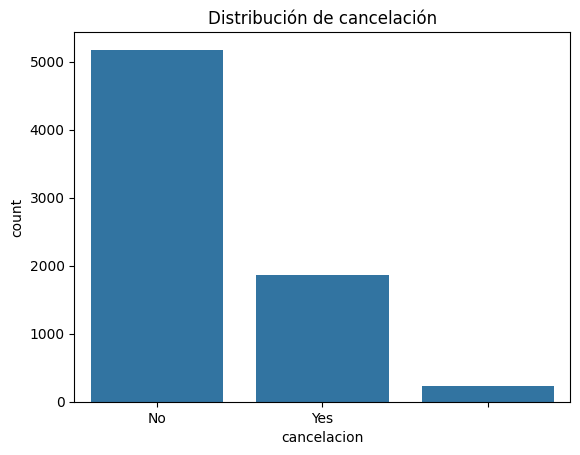

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=datos_clientes_n, x='cancelacion')
plt.title('Distribución de cancelación')
plt.show()

c) Recuento de evasión por variables categóricas

In [ ]:
categoricas = [
    'cliente.genero', 'cliente.pareja', 'cliente.dependientes',
    'telefono.servicio_telefonico', 'telefono.lineas_multiples',
    'internet.servicio_internet', 'internet.seguridad_en_linea',
    'internet.copia_seguridad', 'internet.proteccion_dispositivo',
    'internet.soporte_tecnico', 'internet.tv_streaming',
    'internet.peliculas_streaming', 'cuenta.contrato',
    'cuenta.facturacion_sin_papel', 'cuenta.metodo_pago'
]

for col in categoricas:
    print(f"\n--- {col} ---")
    print(datos_clientes_n[col].value_counts())
    print(datos_clientes_n[col].value_counts(normalize=True) * 100)


--- cliente.genero ---
cliente.genero
Male      3675
Female    3592
Name: count, dtype: int64
cliente.genero
Male      50.571075
Female    49.428925
Name: proportion, dtype: float64

--- cliente.pareja ---
cliente.pareja
No     3749
Yes    3518
Name: count, dtype: int64
cliente.pareja
No     51.589377
Yes    48.410623
Name: proportion, dtype: float64

--- cliente.dependientes ---
cliente.dependientes
No     5086
Yes    2181
Name: count, dtype: int64
cliente.dependientes
No     69.987615
Yes    30.012385
Name: proportion, dtype: float64

--- telefono.servicio_telefonico ---
telefono.servicio_telefonico
Yes    6560
No      707
Name: count, dtype: int64
telefono.servicio_telefonico
Yes    90.271088
No      9.728912
Name: proportion, dtype: float64

--- telefono.lineas_multiples ---
telefono.lineas_multiples
No                  3495
Yes                 3065
No phone service     707
Name: count, dtype: int64
telefono.lineas_multiples
No                  48.094124
Yes                 42.176

d) Conteo de evasión por variables numéricas

In [ ]:
# Convertir cargos_totales a numérico
datos_clientes_n['cuenta.cargos_totales'] = pd.to_numeric(
    datos_clientes_n['cuenta.cargos_totales'], errors='coerce'
)

In [51]:
# Variables numéricas a analizar
numericas = [
    'cliente.antiguedad',
    'cuenta.cargos_mensuales',
    'cuenta.cargos_totales',
    'cuenta_diaria'
]

# Agrupación por cancelación
comparacion = datos_clientes_n.groupby('cancelacion')[numericas].mean()

print("Promedios de variables numéricas según cancelación:\n")
print(comparacion)

# Interpretación
print("\nInterpretación del análisis:\n")

for col in numericas:
    media_cancel = comparacion.loc['Yes', col] if 'Yes' in comparacion.index else comparacion.iloc[1][col]
    media_no_cancel = comparacion.loc['No', col] if 'No' in comparacion.index else comparacion.iloc[0][col]

    print(f"- En la variable '{col}':")
    print(f"    * Clientes que cancelaron: {media_cancel:.2f}")
    print(f"    * Clientes que NO cancelaron: {media_no_cancel:.2f}")

    if media_cancel > media_no_cancel:
        print(f"    → Los clientes que cancelan tienden a tener valores MÁS altos en esta variable.\n")
    else:
        print(f"    → Los clientes que cancelan tienden a tener valores MÁS bajos en esta variable.\n")

Promedios de variables numéricas según cancelación:

             cliente.antiguedad  cuenta.cargos_mensuales  \
cancelacion                                                
                      31.571429                63.412277   
No                    37.569965                61.265124   
Yes                   17.979133                74.441332   

             cuenta.cargos_totales  cuenta_diaria  
cancelacion                                        
                       2196.933705       2.113743  
No                     2555.344141       2.042171  
Yes                    1531.796094       2.481378  

Interpretación del análisis:

- En la variable 'cliente.antiguedad':
    * Clientes que cancelaron: 17.98
    * Clientes que NO cancelaron: 37.57
    → Los clientes que cancelan tienden a tener valores MÁS bajos en esta variable.

- En la variable 'cuenta.cargos_mensuales':
    * Clientes que cancelaron: 74.44
    * Clientes que NO cancelaron: 61.27
    → Los clientes que cancelan t

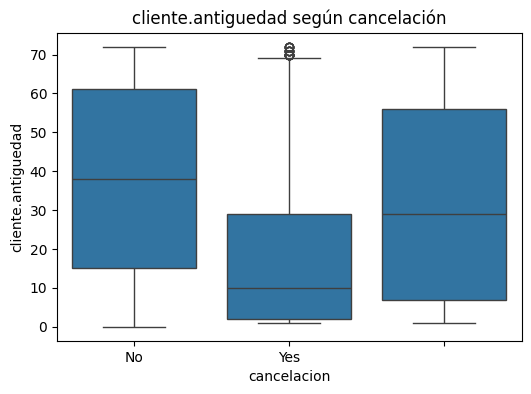

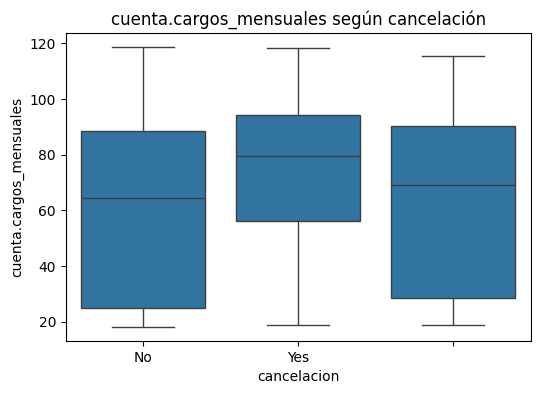

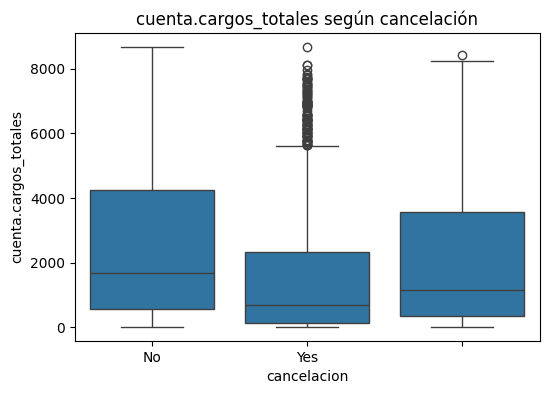

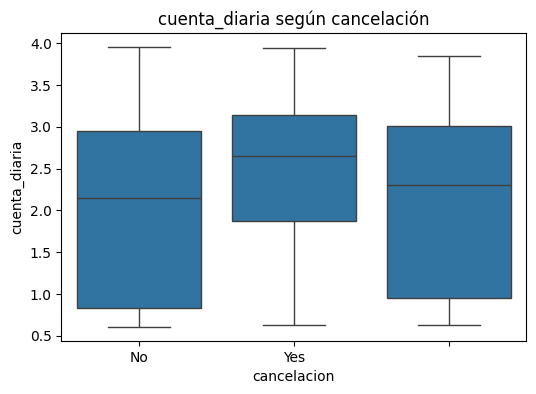

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=datos_clientes_n, x='cancelacion', y=col)
    plt.title(f'{col} según cancelación')
    plt.show()

# **Informe final**